# APHIS Data - Initial Cleaning and Exploration

This is an initial exploration of the APHIS US OPen Bee data set found at https://www.usbeedata.org/state_reports/public_download/

Note: we use the geopandas library which is not part of the Erdos Institute environment. 

In [31]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [32]:
aphis_df = pd.read_csv('../data/raw/aphis/aphis_state_year_data.csv', on_bad_lines='warn', skiprows=[0, 1,3])

In [33]:
aphis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11809 entries, 0 to 11808
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sample_year             11809 non-null  int64  
 1   sample_month_number     11809 non-null  int64  
 2   sample_month            11809 non-null  object 
 3   state_code              11809 non-null  object 
 4   sampling_county         11581 non-null  object 
 5   varroa_per_100_bees     11710 non-null  float64
 6   million_spores_per_bee  11710 non-null  float64
 7   abpv                    11269 non-null  object 
 8   abpv_percentile         1549 non-null   object 
 9   amsv1                   2371 non-null   object 
 10  amsv1_percentile        182 non-null    object 
 11  cbpv                    11060 non-null  object 
 12  cbpv_percentile         1127 non-null   object 
 13  dwv                     11418 non-null  object 
 14  dwv_percentile          7438 non-null 

In [4]:
aphis_df.head()

,sample_year,sample_month_number,sample_month,state_code,sampling_county,varroa_per_100_bees,million_spores_per_bee,abpv,abpv_percentile,amsv1,...,iapv_percentile,kbv,kbv_percentile,lsv2,lsv2_percentile,sbpv,sbpv_percentile,mkv,mkv_percentile,pesticides
0,2009,7,July,HI,Hawaii,2.41,4.18,NaN,NaN,NaN,...,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN
1,2009,7,July,HI,Honolulu,3.46,0.03,NaN,NaN,NaN,...,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN
2,2009,7,July,HI,Honolulu,11.48,0.03,NaN,NaN,NaN,...,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN
3,2009,7,July,HI,Honolulu,14.00,0.08,NaN,NaN,NaN,...,NaN,+,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN
4,2009,7,July,HI,Honolulu,1.15,0.03,NaN,NaN,NaN,...,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN


In [5]:
aphis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11809 entries, 0 to 11808
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sample_year             11809 non-null  int64  
 1   sample_month_number     11809 non-null  int64  
 2   sample_month            11809 non-null  object 
 3   state_code              11809 non-null  object 
 4   sampling_county         11581 non-null  object 
 5   varroa_per_100_bees     11710 non-null  float64
 6   million_spores_per_bee  11710 non-null  float64
 7   abpv                    11269 non-null  object 
 8   abpv_percentile         1549 non-null   object 
 9   amsv1                   2371 non-null   object 
 10  amsv1_percentile        182 non-null    object 
 11  cbpv                    11060 non-null  object 
 12  cbpv_percentile         1127 non-null   object 
 13  dwv                     11418 non-null  object 
 14  dwv_percentile          7438 non-null 

In [34]:
# Replace '+' with 1 and '-' with 0
aphis_df['abpv'] = aphis_df['abpv'].map({'+': 1, '-': 0})
aphis_df['cbpv'] = aphis_df['cbpv'].map({'+': 1, '-': 0})
aphis_df['dwv'] = aphis_df['dwv'].map({'+': 1, '-': 0})
aphis_df['dwv-b'] = aphis_df['dwv-b'].map({'+': 1, '-': 0})
aphis_df['iapv'] = aphis_df['iapv'].map({'+': 1, '-': 0})
aphis_df['kbv'] = aphis_df['kbv'].map({'+': 1, '-': 0})
aphis_df['lsv2'] = aphis_df['lsv2'].map({'+': 1, '-': 0})
aphis_df['sbpv'] = aphis_df['sbpv'].map({'+': 1, '-': 0})
aphis_df['mkv'] = aphis_df['mkv'].map({'+': 1, '-': 0})



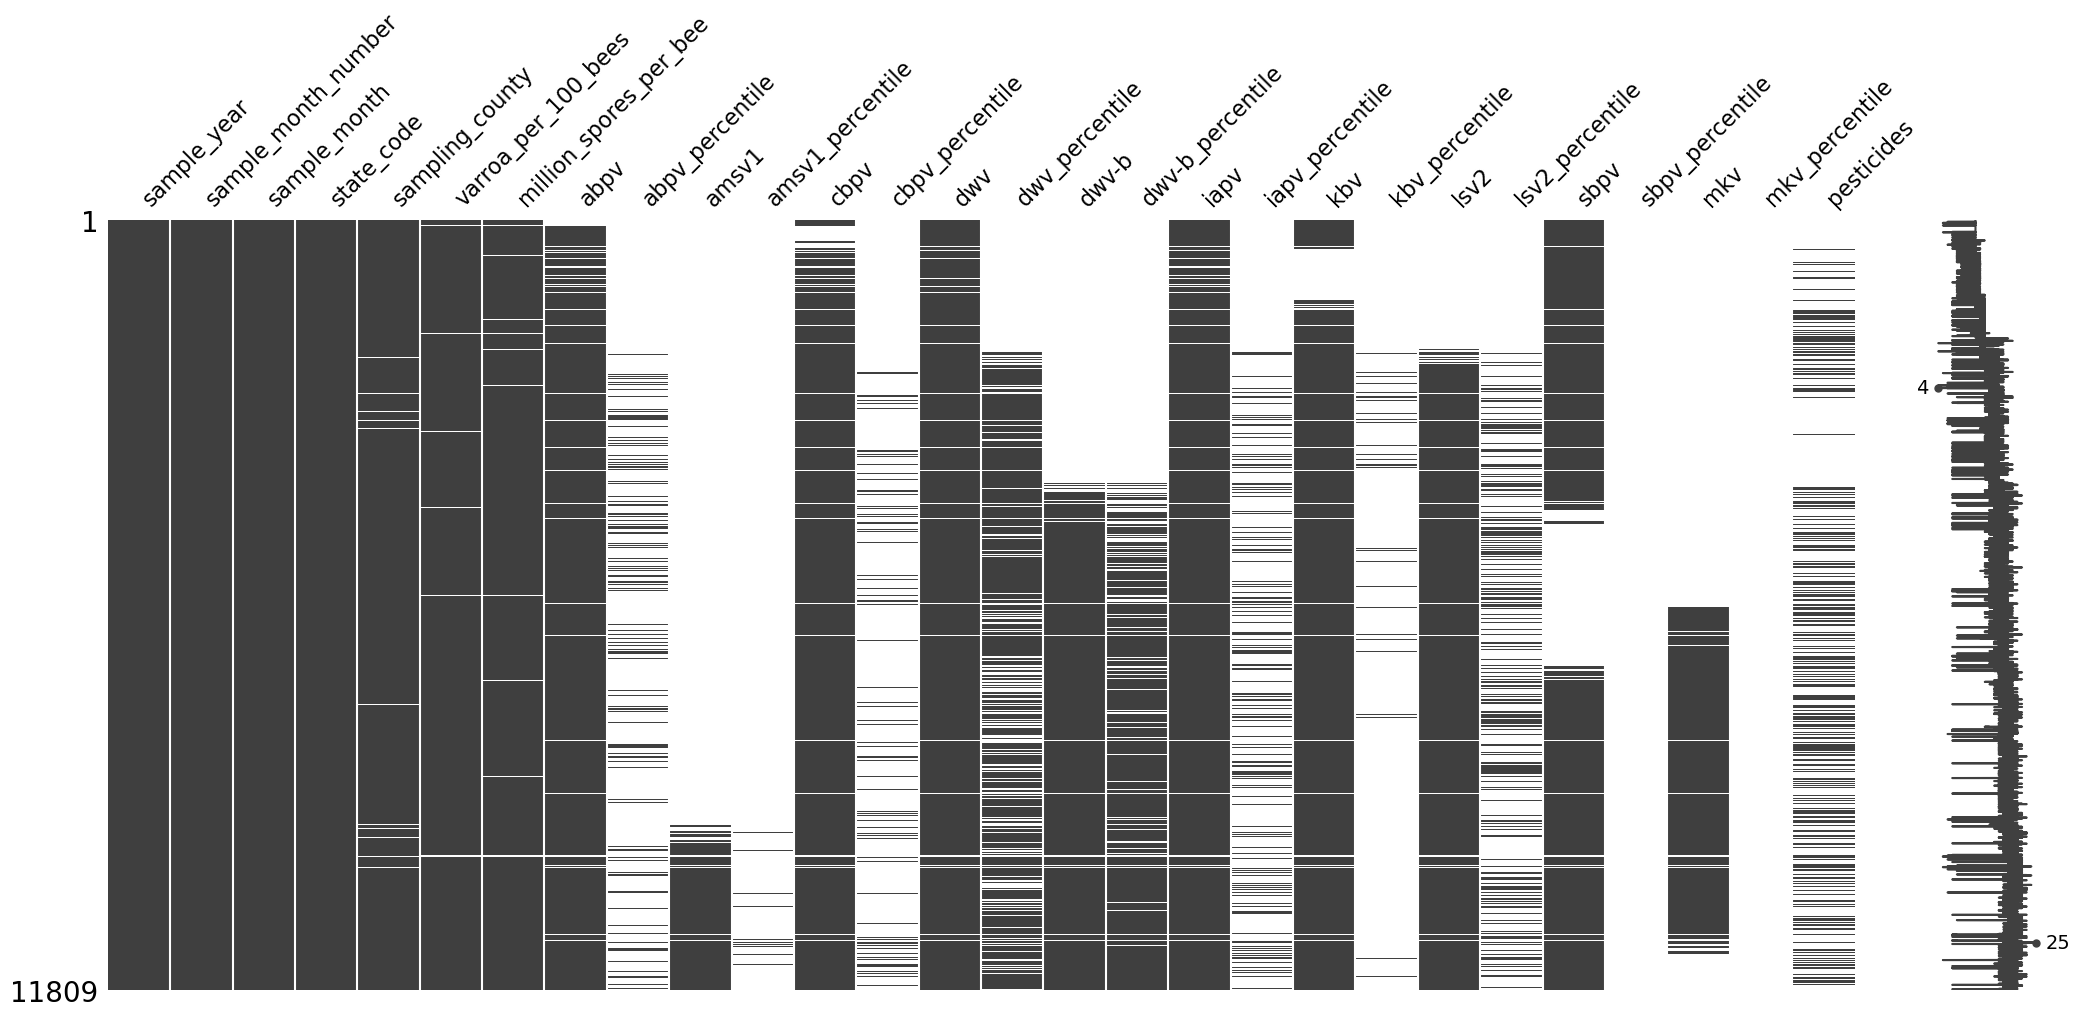

In [35]:
import missingno as msno
msno.matrix(aphis_df)
plt.show()

In [36]:
# Load US counties and states geometry from the US census
counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_5m.zip")
counties = counties[['STATEFP', 'NAME', 'GEOID', 'geometry']]

states = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_5m.zip")
# Remove territories
states = states[~states['STUSPS'].isin(['AS', 'GU', 'MP', 'PR', 'VI'])]


We will need to use the Federal Information Processing Series (FIPS) codes for states - so we'll add that to our aphis data. 

In [37]:
state_fips_map = {
    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08',
    'CT': '09', 'DE': '10', 'DC': '11', 'FL': '12', 'GA': '13', 'HI': '15',
    'ID': '16', 'IL': '17', 'IN': '18', 'IA': '19', 'KS': '20', 'KY': '21',
    'LA': '22', 'ME': '23', 'MD': '24', 'MA': '25', 'MI': '26', 'MN': '27',
    'MS': '28', 'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32', 'NH': '33',
    'NJ': '34', 'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39',
    'OK': '40', 'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46',
    'TN': '47', 'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53',
    'WV': '54', 'WI': '55', 'WY': '56'
}

In [38]:
aphis_df['state_fips'] = aphis_df['state_code'].map(state_fips_map)


In [39]:
aphis_df.head(5)

,sample_year,sample_month_number,sample_month,state_code,sampling_county,varroa_per_100_bees,million_spores_per_bee,abpv,abpv_percentile,amsv1,...,kbv,kbv_percentile,lsv2,lsv2_percentile,sbpv,sbpv_percentile,mkv,mkv_percentile,pesticides,state_fips
0,2009,7,July,HI,Hawaii,2.41,4.18,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,15
1,2009,7,July,HI,Honolulu,3.46,0.03,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,15
2,2009,7,July,HI,Honolulu,11.48,0.03,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,15
3,2009,7,July,HI,Honolulu,14.00,0.08,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,15
4,2009,7,July,HI,Honolulu,1.15,0.03,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,15


In [40]:
counties.columns

Index(['STATEFP', 'NAME', 'GEOID', 'geometry'], dtype='object')

In [41]:
merged = counties.merge(
    aphis_df, 
    left_on=['STATEFP', 'NAME'], 
    right_on=['state_fips', 'sampling_county'],
    how='inner'
    )


We'll start by visualizing the data county-wise on a map. We'll make the plot interactive with dropdown menus for the month and the pathogen plotted. 

In [17]:
def plot_month(month,pathogen):
    subset = merged[merged['sample_month'] == month]
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    subset.plot(column=pathogen, cmap='viridis', linewidth=0.1, ax=ax, edgecolor='black', legend=True)
    states.boundary.plot(ax=ax, color='black', linewidth=0.1)
    ax.set_xlim([-180,-60]) #quick and dirty hack to remove Alaskan Islands that appear on the far right with the default projection 
    plt.axis('off')
    ax.set_title("Pathogen Data by County", fontsize=14)
    plt.show()

In [42]:
month_dropdown = widgets.Dropdown(
    options=[(f'{m}', m) for m in ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']],
    value='January',
    description='Month:',
)

pathogen_dropdown = widgets.Dropdown(
    options=[('Varroa Mites', 'varroa_per_100_bees'), ('Nosema Spore Levels','million_spores_per_bee'), ('Acute Bee Paralysis Virus','abpv'), ('Chronic Bee Paralysis Virus','cbpv'),('Deformed Wind Virus A','dwv'), ('Deformed Wind Virus B','dwv-b'), ('Israeli Acute Paralysis Virus','iapv'), ('Kashmir Bee Virus', 'kbv'), ( 'Lake Sinai Virus 2', 'lsv2'), ( 'Slow Bee Paralysis Virus', 'sbpv'), ('Moku Virus', 'mkv')],
    value='varroa_per_100_bees',
    description='Pathogen:',
)

widgets.interact(plot_month, month=month_dropdown, pathogen=pathogen_dropdown)

interactive(children=(Dropdown(description='Month:', options=(('January', 'January'), ('February', 'February')…

<function __main__.plot_month(month, pathogen)>

Note: only the Verroa mite count and the Nosema spores are floating point values. The remainder of the viruses are reported as present or not present in a sample (and thus are plotted as a 0 or 1). 

Observations: 
* The counties where samples are collected varies from month to month - perhaps it would be best to consider a state or regional measure? 
* The last two pathogens (Slow bee paralysis virus and Moku virus) have nearly no prevelance. Perhaps we should drop this data?   

# Include Climate Region

We'll now consider the data on the course scale of climate regions rather than county scale. We will use a definition from NOAA. See https://www.ncei.noaa.gov/access/monitoring/reference-maps/us-climate-regions for regions.

Other avenues for exploration might include: 
2012 IECC Climate Zones (Data table here: https://www.osti.gov/dataexplorer/biblio/dataset/1617637)
DOE - definition by county: https://www.energy.gov/sites/prod/files/2015/10/f27/ba_climate_region_guide_7.3.pdf

However the NASS data set is collected by state, therefore we will continue with the NOAA designation. 

In [43]:
state_to_region = {
    "AL": "Southeast",
    "AK": "Northwest",
    "AZ": "Southwest",
    "AR": "South",
    "CA": "West",
    "CO": "Southwest",
    "CT": "Northeast",
    "DE": "Northeast",
    "FL": "Southeast",
    "GA": "Southeast",
    "HI": "Hawaii",
    "ID": "Northwest",
    "IL": "Ohio Valley",
    "IN": "Ohio Valley",
    "IA": "Upper Midwest",
    "KS": "South",
    "KY": "Ohio Valley",
    "LA": "South",
    "ME": "Northeast",
    "MD": "Northeast",
    "MA": "Northeast",
    "MI": "Upper Midwest",
    "MN": "Upper Midwest",
    "MS": "Southeast",
    "MO": "South",
    "MT": "Northern Rockies & Plains",
    "NE": "Northern Rockies & Plains",
    "NV": "Southwest",
    "NH": "Northeast",
    "NJ": "Northeast",
    "NM": "Southwest",
    "NY": "Northeast",
    "NC": "Southeast",
    "ND": "Northern Rockies & Plains",
    "OH": "Ohio Valley",
    "OK": "South",
    "OR": "Northwest",
    "PA": "Northeast",
    "RI": "Northeast",
    "SC": "Southeast",
    "SD": "Northern Rockies & Plains",
    "TN": "Southeast",
    "TX": "South",
    "UT": "Southwest",
    "VT": "Northeast",
    "VA": "Southeast",
    "WA": "Northwest",
    "WV": "Ohio Valley",
    "WI": "Upper Midwest",
    "WY": "Northern Rockies & Plains"
}


In [44]:
aphis_df['region']=aphis_df['state_code'].map(state_to_region)
aphis_df.head()
aphis_df.columns

Index(['sample_year', 'sample_month_number', 'sample_month', 'state_code',
       'sampling_county', 'varroa_per_100_bees', 'million_spores_per_bee',
       'abpv', 'abpv_percentile', 'amsv1', 'amsv1_percentile', 'cbpv',
       'cbpv_percentile', 'dwv', 'dwv_percentile', 'dwv-b', 'dwv-b_percentile',
       'iapv', 'iapv_percentile', 'kbv', 'kbv_percentile', 'lsv2',
       'lsv2_percentile', 'sbpv', 'sbpv_percentile', 'mkv', 'mkv_percentile',
       'pesticides', 'state_fips', 'region'],
      dtype='object')

The NASS dataset goes from 2015-2024. The APHIS data is a bit sparse in the initial years. We will drop years 2009-1024. 

In [45]:
aphis_df = aphis_df[~aphis_df['sample_year'].between(2009, 2014)]
aphis_df = aphis_df.drop(columns=['sbpv', 'sbpv_percentile', 'mkv', 'mkv_percentile'], axis=1)

In [46]:

aphis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8718 entries, 3091 to 11808
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sample_year             8718 non-null   int64  
 1   sample_month_number     8718 non-null   int64  
 2   sample_month            8718 non-null   object 
 3   state_code              8718 non-null   object 
 4   sampling_county         8619 non-null   object 
 5   varroa_per_100_bees     8647 non-null   float64
 6   million_spores_per_bee  8653 non-null   float64
 7   abpv                    8524 non-null   float64
 8   abpv_percentile         1343 non-null   object 
 9   amsv1                   2371 non-null   object 
 10  amsv1_percentile        182 non-null    object 
 11  cbpv                    8524 non-null   float64
 12  cbpv_percentile         1009 non-null   object 
 13  dwv                     8524 non-null   float64
 14  dwv_percentile          6586 non-null   o

Now replace the "<30" with 30 in the percentile columns and "Virus Present" with 50 - a mid-level value 

In [52]:
aphis_df['abpv_percentile'] = aphis_df['abpv_percentile'].replace("<30", 30)
aphis_df['abpv_percentile'] = pd.to_numeric(aphis_df['abpv_percentile'], errors='coerce')

aphis_df['amsv1_percentile'] = aphis_df['amsv1_percentile'].replace("<30", 30)
aphis_df['amsv1_percentile'] = aphis_df['amsv1_percentile'].replace("Virus Present", 50)
aphis_df['amsv1_percentile'] = pd.to_numeric(aphis_df['amsv1_percentile'], errors='coerce')

aphis_df['cbpv_percentile'] = aphis_df['cbpv_percentile'].replace("<30", 30)
aphis_df['cbpv_percentile'] = aphis_df['cbpv_percentile'].replace("Virus Present", 50)
aphis_df['cbpv_percentile'] = pd.to_numeric(aphis_df['cbpv_percentile'], errors='coerce')

aphis_df['dwv_percentile'] = aphis_df['dwv_percentile'].replace("<30", 30)
aphis_df['dwv_percentile'] = aphis_df['dwv_percentile'].replace("Virus Present", 50)
aphis_df['dwv_percentile'] = pd.to_numeric(aphis_df['dwv_percentile'], errors='coerce')

aphis_df['dwv-b_percentile'] = aphis_df['dwv-b_percentile'].replace("<30", 30)
aphis_df['dwv-b_percentile'] = aphis_df['dwv-b_percentile'].replace("Virus Present", 50)
aphis_df['dwv-b_percentile'] = pd.to_numeric(aphis_df['dwv-b_percentile'], errors='coerce')

aphis_df['iapv_percentile'] = aphis_df['iapv_percentile'].replace("<30", 30)
aphis_df['iapv_percentile'] = aphis_df['iapv_percentile'].replace("Virus Present", 50)
aphis_df['iapv_percentile'] = pd.to_numeric(aphis_df['iapv_percentile'], errors='coerce')

aphis_df['kbv_percentile'] = aphis_df['kbv_percentile'].replace("<30", 30)
aphis_df['kbv_percentile'] = aphis_df['kbv_percentile'].replace("Virus Present", 50)
aphis_df['kbv_percentile'] = pd.to_numeric(aphis_df['kbv_percentile'], errors='coerce')

aphis_df['lsv2_percentile'] = aphis_df['lsv2_percentile'].replace("<30", 30)
aphis_df['lsv2_percentile'] = aphis_df['lsv2_percentile'].replace("Virus Present", 50)
aphis_df['lsv2_percentile'] = pd.to_numeric(aphis_df['lsv2_percentile'], errors='coerce')


# Combine Monthly to Quarterly  
The hive collapse data available from NASS is on a quarterly basis - so we will combine the monthly data to be quarterly. 

In [53]:
# months-to-quarters dictionary
month_to_quarter = {
    'January': 'Q1',
    'February': 'Q1',
    'March': 'Q1',
    'April': 'Q2',
    'May': 'Q2',
    'June': 'Q2',
    'July': 'Q3',
    'August': 'Q3',
    'September': 'Q3',
    'October': 'Q4',
    'November': 'Q4',
    'December': 'Q4'
}

# Apply the mapping to create a new column
aphis_df['quarter'] = aphis_df['sample_month'].map(month_to_quarter)

Now we will reduce the data to the the state scale. For varroa mites we will include 2 columns: max and average. We will not include a minimum since all states across the data have a minimum of 0 when there is data. ** We will need to decide how to handle NaN. **

** For another time - could possibly weight county-level data by the land use in each county**

For the presence of a virus - start with present being TRUE and nopresent OR no data being FALSE

In [55]:
quarterly_aphis_df = (
    aphis_df
    .groupby(['sample_year', 'state_code','region', 'quarter'])
    .agg(
        mean_varroa=('varroa_per_100_bees', 'mean'), 
        max_varroa=('varroa_per_100_bees', 'max'), 
        nosema=('million_spores_per_bee', 'mean'), 
        abpv=('abpv_percentile', 'mean'),
        amsv1=('amsv1_percentile', 'mean'), 
        cbpv=('cbpv_percentile', 'mean'),        
        dwv=('dwv_percentile', 'mean'),
        dwvb=('dwv-b_percentile', 'mean'),
        iapv=('iapv_percentile', 'mean'),
        kbv=('kbv_percentile', 'mean'),
        lsv2=('lsv2_percentile', 'mean'),
        )
    .reset_index()
)

quarterly_aphis_df.head(10)

,sample_year,state_code,region,quarter,mean_varroa,max_varroa,nosema,abpv,amsv1,cbpv,dwv,dwvb,iapv,kbv,lsv2
0,2015,AL,Southeast,Q2,2.366000,8.00,0.143333,NaN,NaN,50.0,52.500000,NaN,30.0,90.0,38.571429
1,2015,AL,Southeast,Q3,4.143000,12.09,0.090000,90.000000,NaN,NaN,61.250000,NaN,NaN,40.0,30.000000
2,2015,AL,Southeast,Q4,9.085000,10.98,0.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,30.000000
3,2015,AR,South,Q2,2.397273,6.43,0.013636,NaN,NaN,70.0,56.000000,NaN,NaN,NaN,43.333333
4,2015,AR,South,Q3,3.748333,8.11,0.020833,50.000000,NaN,90.0,68.181818,NaN,80.0,NaN,45.000000
5,2015,CA,West,Q1,0.791176,5.45,2.417647,48.333333,NaN,30.0,61.333333,NaN,30.0,80.0,72.857143
6,2015,CA,West,Q2,0.899091,5.17,0.200000,30.000000,NaN,60.0,30.000000,NaN,40.0,30.0,32.500000
7,2015,CA,West,Q4,1.950000,11.76,0.116667,53.750000,NaN,NaN,58.571429,NaN,30.0,50.0,60.000000
8,2015,CT,Northeast,Q2,0.390000,0.78,3.175000,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,80.000000
9,2015,CT,Northeast,Q3,2.328636,16.19,0.131818,NaN,NaN,30.0,40.000000,NaN,NaN,NaN,46.000000


We need to decide what to do with the NaN values. 

In [ ]:
# quarterly_aphis_df=quarterly_aphis_df.fillna(0)
# quarterly_aphis_df.head(10)

,sample_year,state_code,region,quarter,mean_varroa,max_varroa,nosema,abpv,amsv1,cbpv,dwv,dwvb,iapv,kbv,lsv2
0,2015,AL,Southeast,Q2,2.366000,8.00,0.143333,0.000000,0.0,50.0,52.500000,0.0,30.0,90.0,38.571429
1,2015,AL,Southeast,Q3,4.143000,12.09,0.090000,90.000000,0.0,0.0,61.250000,0.0,0.0,40.0,30.000000
2,2015,AL,Southeast,Q4,9.085000,10.98,0.000000,0.000000,0.0,0.0,60.000000,0.0,0.0,0.0,30.000000
3,2015,AR,South,Q2,2.397273,6.43,0.013636,0.000000,0.0,70.0,56.000000,0.0,0.0,0.0,43.333333
4,2015,AR,South,Q3,3.748333,8.11,0.020833,50.000000,0.0,90.0,68.181818,0.0,80.0,0.0,45.000000
5,2015,CA,West,Q1,0.791176,5.45,2.417647,48.333333,0.0,30.0,61.333333,0.0,30.0,80.0,72.857143
6,2015,CA,West,Q2,0.899091,5.17,0.200000,30.000000,0.0,60.0,30.000000,0.0,40.0,30.0,32.500000
7,2015,CA,West,Q4,1.950000,11.76,0.116667,53.750000,0.0,0.0,58.571429,0.0,30.0,50.0,60.000000
8,2015,CT,Northeast,Q2,0.390000,0.78,3.175000,0.000000,0.0,0.0,30.000000,0.0,0.0,0.0,80.000000
9,2015,CT,Northeast,Q3,2.328636,16.19,0.131818,0.000000,0.0,30.0,40.000000,0.0,0.0,0.0,46.000000
